# BRCA all omics benchmark
- benchmark for the brca dataset
- take
    - [x] mRNA
    - [x] CNA
    - [x] miRNA
    - [ ] DNA methylation data
- benchmark several prediction methods on them, using
    - [ ] early integration
    - [ ] late integration

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import numpy as np
import polars as pl
import torch
import torch_geometric as pyg
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

from bipartite_gnn.graph_visualizatons import visualize_graph, visualize_embeddings
from baseline_evals.feature_selection import variance_filtering, class_variational_selection
from baseline_evals.knn_eval import knn_eval
from baseline_evals.svm_eval import svm_eval
from baseline_evals.xgboost_eval import xgboost_eval
from baseline_evals.mlp_eval import mlp_eval

SyntaxError: no binding for nonlocal 'select_masks' found (mlp_eval.py, line 211)

In [ ]:
null_vals = ["NA"]
mrna = pl.read_csv("BRCA_PROCESSED_DATA/mrna.tsv", separator="\t", null_values=null_vals)
cna = pl.read_csv("BRCA_PROCESSED_DATA/cnvth.tsv", separator="\t", null_values=null_vals)
mirna = pl.read_csv("BRCA_PROCESSED_DATA/mirna.tsv", separator="\t", null_values=null_vals)

In [4]:
labels = pl.read_csv("BRCA_PROCESSED_DATA/labels.tsv", separator="\t")
le = LabelEncoder()
le.fit(labels["PAM50_mRNA_nature2012"].to_list())
y = le.transform(labels["PAM50_mRNA_nature2012"].to_list())
labels, y

(shape: (483, 2)
 ┌─────────────────┬───────────────────────┐
 │ sampleID        ┆ PAM50_mRNA_nature2012 │
 │ ---             ┆ ---                   │
 │ str             ┆ str                   │
 ╞═════════════════╪═══════════════════════╡
 │ TCGA-A1-A0SD-01 ┆ Luminal A             │
 │ TCGA-A1-A0SE-01 ┆ Luminal A             │
 │ TCGA-A1-A0SH-01 ┆ Luminal A             │
 │ TCGA-A1-A0SJ-01 ┆ Luminal A             │
 │ TCGA-A1-A0SK-01 ┆ Basal-like            │
 │ …               ┆ …                     │
 │ TCGA-E2-A1B4-01 ┆ Luminal A             │
 │ TCGA-E2-A1B5-01 ┆ Basal-like            │
 │ TCGA-E2-A1B6-01 ┆ Luminal A             │
 │ TCGA-E2-A1BC-01 ┆ Luminal A             │
 │ TCGA-E2-A1BD-01 ┆ Luminal A             │
 └─────────────────┴───────────────────────┘,
 array([2, 2, 2, 2, 0, 3, 0, 2, 0, 0, 3, 0, 0, 2, 1, 1, 2, 1, 0, 2, 2, 2,
        3, 2, 2, 3, 0, 1, 0, 2, 3, 2, 2, 2, 1, 3, 2, 2, 2, 2, 2, 2, 3, 0,
        2, 3, 3, 0, 2, 0, 1, 0, 3, 3, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 0

In [5]:
# ensure that the omic channels are alined with the labels and with each other
assert mrna.columns[1:] == cna.columns[1:] == mirna.columns[1:] == labels["sampleID"].to_list()

In [26]:
# TODO, join genes with identical features into a single vertex
def find_identical_rows(matrix):
    # Convert the matrix to a structured array
    structured_array = np.core.records.fromarrays(matrix.transpose())
    
    # Find unique rows and their corresponding labels
    _, labels = np.unique(structured_array, return_inverse=True)
    
    # Group indices by labels
    unique_labels, indices = np.unique(labels, return_index=True)
    identical_rows_indices = [np.where(labels == label)[0] for label in unique_labels]
    
    return identical_rows_indices

# Example usage
matrix = np.array([[1, 2], [3, 4], [1, 2], [5, 6], [3, 4]])
identical_rows_indices = find_identical_rows(matrix)

for indices in identical_rows_indices:
    print(f"Identical rows at indices: {indices}")

# identical_rows = find_identical_rows(cna_m)

Identical rows at indices: [0 2]
Identical rows at indices: [1 4]
Identical rows at indices: [3]


In [6]:
X_mrna = mrna[:,1:].to_numpy().T
X_cna = cna[:,1:].to_numpy().T
X_mirna = mirna[:,1:].to_numpy().T

X = np.hstack([X_mrna, X_cna, X_mirna])
X.shape

(483, 43982)

## Benchmarks

In [7]:
knn_eval(X, y, n_features=1000, test_size=0.4)

| KNN | 0.65 +/- 0.03 | 0.54 +/- 0.04 | 0.60 +/- 0.04 |
study.best_value=0.599519299270645, study.best_params={'n_neighbors': 1}


In [29]:
svm_eval(X, y, n_trials=20, n_features_preselect=5000, n_features=1000, test_size=0.4, mode="linear")

Trial 1 / 20
Trial 2 / 20
Trial 3 / 20
Trial 4 / 20
Trial 5 / 20
Trial 6 / 20
Trial 7 / 20
Trial 8 / 20
Trial 9 / 20
Trial 10 / 20
Trial 11 / 20
Trial 12 / 20
Trial 13 / 20
Trial 14 / 20
Trial 15 / 20
Trial 16 / 20
Trial 17 / 20
Trial 18 / 20
Trial 19 / 20
Trial 20 / 20
| LIN SVM | 0.81 +/- 0.03 | 0.81 +/- 0.02 | 0.81 +/- 0.03 |
study.best_value=0.8142452090046813, study.best_params={'C': 0.001114063483643202, 'class_weight': None}


{'acc': 0.811340206185567,
 'f1_macro': 0.807820061683382,
 'f1_weighted': 0.8142452090046813,
 'acc_std': 0.029896907216494847,
 'f1_macro_std': 0.02454023617603619,
 'f1_weighted_std': 0.029062426848584122}

In [26]:
svm_eval(X, y, n_trials=20, n_features_preselect=5000, n_features=500, test_size=0.4, mode="rbf")

Trial 1 / 20


ValueError: when `importance_getter=='auto'`, the underlying estimator SVC should have `coef_` or `feature_importances_` attribute. Either pass a fitted estimator to feature selector or call fit before calling transform.

In [8]:
xgboost_eval(X, y, n_features=5000, n_evals=3, test_size=0.4)

0 / 100
| XGBoost | 0.81 +/- 0.04 | 0.79 +/- 0.04 | 0.81 +/- 0.04 |
1 / 100
Pruning trial
2 / 100
Pruning trial
3 / 100
Pruning trial
4 / 100
5 / 100
Pruning trial
6 / 100
| XGBoost | 0.86 +/- 0.02 | 0.84 +/- 0.03 | 0.85 +/- 0.02 |
7 / 100
8 / 100
Pruning trial
9 / 100
Pruning trial
10 / 100
Pruning trial
11 / 100
Pruning trial
12 / 100
Pruning trial
13 / 100
Pruning trial
14 / 100
Pruning trial
15 / 100
Pruning trial
16 / 100
Pruning trial
17 / 100
Pruning trial
18 / 100
Pruning trial
19 / 100
Pruning trial
20 / 100
21 / 100
22 / 100
23 / 100
Pruning trial
24 / 100
| XGBoost | 0.86 +/- 0.02 | 0.84 +/- 0.03 | 0.86 +/- 0.02 |
25 / 100
Pruning trial
26 / 100
Pruning trial
27 / 100
28 / 100
Pruning trial
29 / 100
Pruning trial
30 / 100
Pruning trial
31 / 100
Pruning trial
32 / 100
33 / 100
Pruning trial
34 / 100
35 / 100
Pruning trial
36 / 100
Pruning trial
37 / 100
38 / 100
Pruning trial
39 / 100
Pruning trial
40 / 100
41 / 100
42 / 100
43 / 100
44 / 100
Pruning trial
45 / 100
Pruning tr

In [32]:
mlp_eval(X, y, n_trials=1, n_evals=5, n_features=3000, val_test_size=0.4)

Trial 0 / 1
Eval 1 / 5
Eval 2 / 5
Eval 3 / 5
Eval 4 / 5
Eval 5 / 5
[0.83096588 0.86908144 0.76254737 0.77769887 0.79237688]
[0.84712742 0.83014416 0.74728212 0.75667243 0.76780609]
[0.83367596 0.86811491 0.76210262 0.77625904 0.78904093]
{'acc': 0.8065340876579284, 'f1_macro': 0.7898064441853304, 'f1_weighted': 0.8058386933314431, 'acc_std': 0.038667325887467636, 'f1_macro_std': 0.04075051309998024, 'f1_weighted_std': 0.03930192340998711}
study.best_value=2.402179225174702, study.best_params={'l1_lambda': 0.0009684077960192374, 'batch_sz': 64, 'proj_dim': 108, 'dropout': 0.48938880942071467, 'hidden_channels': 48}
| MLP | 0.81 +/- 0.04 | 0.79 +/- 0.04 | 0.81 +/- 0.04 |


In [7]:
from baseline_evals.mlp_eval import MLP

mlp_best = MLP(3000, 4, 47, [47, 70], 0.4)
mlp_best.load_state_dict(torch.load("mlp_best_model.pth"))

<All keys matched successfully>

In [8]:
mlp_best.hidden_layers[0].weight.shape, mlp_best.hidden_layers[0].bias.shape
mlp_best.proj.weight.shape, mlp_best.proj.bias.shape

(torch.Size([47, 3000]), torch.Size([47]))

In [28]:
feat_importances = mlp_best.proj.weight.sum(dim=0)

In [ ]:
mlp_best.proj.we

In [29]:
(torch.round(feat_importances, 4) == 0).sum()

tensor(0)

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
          1.,   0.,   1.,   0.,   2.,   2.,   1.,   0.,   2.,   4.,   1.,
          4.,   5.,   4.,  11.,   7.,   8.,   5.,   9.,  20.,  13.,  11.,
         22.,  26.,  27.,  30.,  34.,  34.,  54.,  70., 101., 108., 140.,
        226., 358., 471., 296., 203., 156.,  88.,  81.,  63.,  52.,  39.,
         30.,  28.,  18.,  13.,  15.,   8.,  12.,  15.,  10.,  10.,   2.,
          6.,   4.,   5.,   8.,   4.,   3.,   1.,   4.,   2.,   0.,   2.,
          1.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   1.,
          0.,   2.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([-0.20798662, -0.20349708, -0.19900754, -0.194518  , -0.19002846,
        -0.18553892, -0.18104938, -0.17655984, -0.17207029, -0.16758077,
        -0.16309123, -0.15860169, -0.15411215, -0.1496226 , -0.14513306,
        -0.14064352, -0.13615398, -0.13166444, -0.1271749 , -0.12268536,
        -0.11819582, -0.11

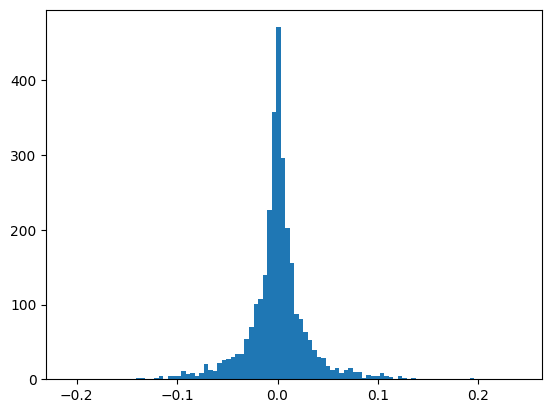

In [9]:
from matplotlib import pyplot as plt

plt.hist(mlp_best.proj.weight.sum(dim=0).detach().numpy(), bins=100)

study.best_value=2.5192529195151394

study.best_params={'l1_lambda': 0.0015844617502738152, 'batch_sz': 64, 'proj_dim': 47, 'dropout': 0.4237635831392694, 'hidden_channels': 70}

| MLP | 0.85 +/- 0.02 | 0.82 +/- 0.04 | 0.85 +/- 0.03 |

w/o l1 reg on the first layer

| MLP | 0.77 +/- 0.02 | 0.73 +/- 0.05 | 0.76 +/- 0.02 |

In [ ]:
# bipartite graph
